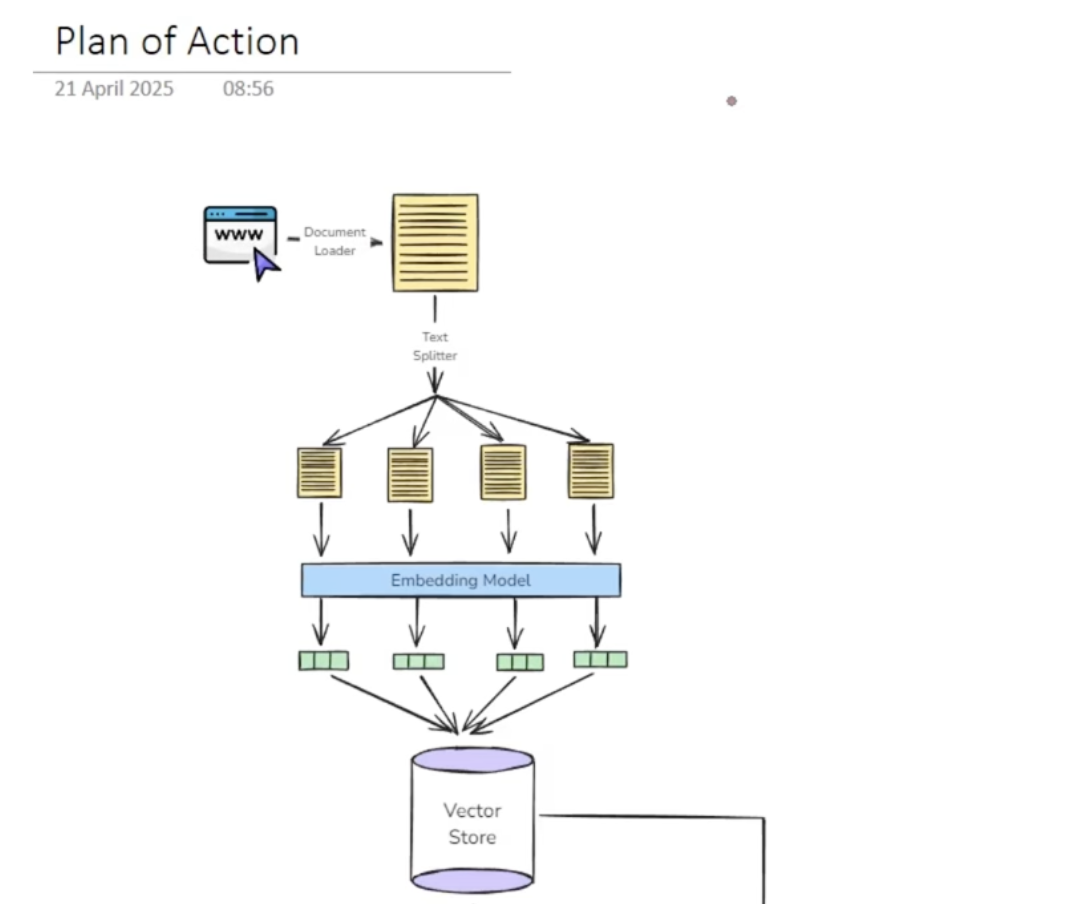

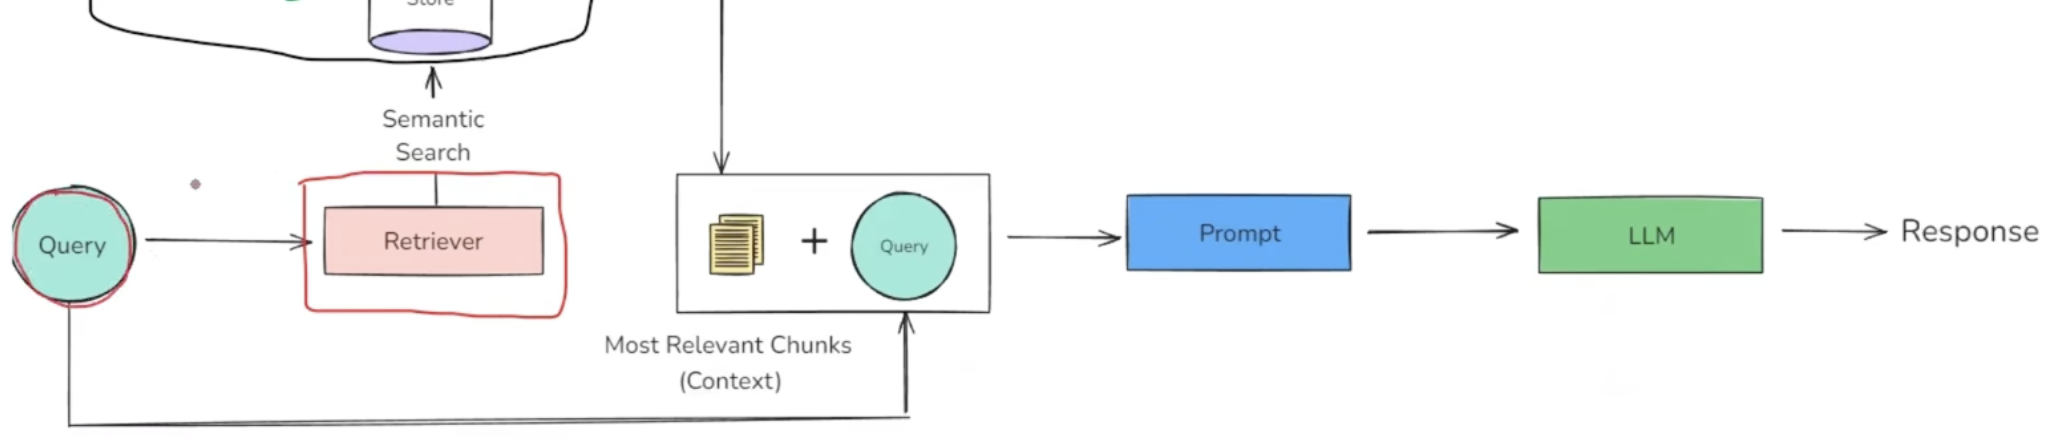

In [1]:
pip install youtube-transcript-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 6.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [17]:
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_ollama import OllamaLLM

<h1 style="color:rgb(255, 98, 0);">Step 1 - Indexing</h1>

### i. Document Ingestion

In [6]:
video_id = "w0H1-b044KY" # only the ID, not full URL
try:
    # If you don’t care which language, this returns the “best” one
    transcript_list = YouTubeTranscriptApi.get_transcript(video_id, languages=["en"])

    # Flatten it to plain text
    transcript = " ".join(chunk["text"] for chunk in transcript_list)
    print(transcript)

except TranscriptsDisabled:
    print("No captions available for this video.")

two years ago I taught myself how to build AI agents without any prior experience in AI and since then I've started multiple AI businesses that have generated over $5 million in revenue i've grown from 0 to 450,000 subscribers here on YouTube and I've built AI agents for some of the biggest companies in the world it's pretty safe to say that learning how to build AI agents has completely changed my life so in this full course I'm going to teach you everything and I mean everything that I have learned over the past 2 years about building and more importantly making money with AI agents even if you don't know how to code my hope is that you too can learn and use this incredibly powerful skill in order to build the life of your dreams before these AI agents start taking our jobs as you can see by the length of this video I'm not going to be holding anything back so in order to make it a bit easier to consume we're going to be splitting it into three different chapters first we'll build yo

In [7]:
transcript_list

[{'text': 'two years ago I taught myself how to',
  'start': 0.16,
  'duration': 3.519},
 {'text': 'build AI agents without any prior',
  'start': 1.839,
  'duration': 4.081},
 {'text': "experience in AI and since then I've",
  'start': 3.679,
  'duration': 4.001},
 {'text': 'started multiple AI businesses that have',
  'start': 5.92,
  'duration': 4.24},
 {'text': 'generated over $5 million in revenue',
  'start': 7.68,
  'duration': 5.28},
 {'text': "i've grown from 0 to 450,000 subscribers",
  'start': 10.16,
  'duration': 5.2},
 {'text': "here on YouTube and I've built AI agents",
  'start': 12.96,
  'duration': 4.159},
 {'text': 'for some of the biggest companies in the',
  'start': 15.36,
  'duration': 3.04},
 {'text': "world it's pretty safe to say that",
  'start': 17.119,
  'duration': 3.201},
 {'text': 'learning how to build AI agents has',
  'start': 18.4,
  'duration': 3.68},
 {'text': 'completely changed my life so in this',
  'start': 20.32,
  'duration': 3.199},
 {'text'

### ii. Text Splitting

In [8]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.create_documents([transcript])

In [9]:
len(chunks)

321

In [10]:
chunks[100]

Document(metadata={}, page_content="to tell it what tools it has available this is really key across all the agents you build especially if they're more conversational you need to explain to them what tools they have and how and when they should use them so if I go you have three powerful tools research company um yep that's right purpose input company URL use when needing to gather company information this one of course is the uh prospect and then this last one is our [Music] pre there we go so that's all whacked in there don't need to worry about that too much but again this will be included um this prompt and everything if you want to follow along and also if you just want to clone the whole agent um and use it in your own business or sell it or whatever you want to do we also get to select the model here um I'm just going to keep it as GPT4 mini i like some pretty fast responses here because agents as someone's using it it can feel really irritating if it's not responding quickly s

### Step iii & iv - Embedding Generation and Storing in Vector Store

In [12]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)

In [13]:
vector_store.index_to_docstore_id

{0: '1e397f7e-ed10-4a3c-a384-a7ff3bd35290',
 1: '45d51333-b44c-4a86-8877-0bdae6d5a37b',
 2: 'd9c6f983-acba-45a1-b21d-d544b9677120',
 3: '6fb92110-6047-4efd-b65b-16de35229347',
 4: 'edc0ef21-43cf-437a-a0ed-531eb5b08484',
 5: '1bcf9dd9-5c2a-48f7-9c0d-1c3c935b3d5c',
 6: '90c39756-6fd8-4b8e-966b-886d6e978f10',
 7: '534bb207-bb3b-4406-b000-f1e112d8f693',
 8: '59d73057-2145-43d7-8e82-d137cbff0234',
 9: '1390197e-c47a-4f05-8b49-38d8e9a98ba3',
 10: '6c18db4d-feb6-41ab-a344-912ebb542805',
 11: 'e2db5e18-b327-4257-8740-eaed49abdd1a',
 12: '0af02b0b-9646-43a8-a223-8a9fd2b40407',
 13: '4eff4a86-4a54-40cd-b958-c36e06a077cd',
 14: '59d03e6f-3f78-407f-b76e-24d70785707a',
 15: '394d7889-4533-483d-b674-9c425c5f61c1',
 16: '86c12936-cb71-434b-a75a-22a4824f4a33',
 17: 'e8c73ed6-7d49-4466-861d-84537d9be2ba',
 18: 'd1cd6b59-fefb-4ce9-8cbd-e7aca3468cdd',
 19: '7ae7e027-c101-4c83-8431-4c697d79db8d',
 20: '1531b486-8eed-41f2-9ffa-70968b5f779b',
 21: '24b07cc9-f845-4a62-8646-2f4c02729941',
 22: '90397109-9dd5-

<h1 style="color:rgb(255, 98, 0);">Step 2 - Retrieval</h1>

In [14]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [15]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x1741a9df0>, search_kwargs={'k': 4})

In [16]:
retriever.invoke('What is the main topic of the video?')

[Document(metadata={}, page_content="as well and finally if you made it this far could you please do me a favor leave a like on the video and drop a comment down below let me know what you like the most what you want to see more of click the share button send it to your friends and family and loved ones so they can start learning these skills too all of these actions really help my video to reach more people in the YouTube algorithm and if you subscribe to the channel you'll be able to see a lot more content like this helping you to understand AI and more so how to build businesses around this incredible opportunity and if you're still hungry for more and you want to watch my complete guide to building an AI business that's going to be linked up here but that is all for the video i'm so excited for you to get cracking on this i sincerely hope you've got something out of this because I put a lot of work into it as did my team so I'm just really really wishing you all all the all all the

<h1 style="color:rgb(255, 98, 0);">Step 3 - Augmentation</h1>

In [19]:
prompt = PromptTemplate(
    template="""
      You are a helpful assistant.
      Answer ONLY from the provided transcript context.
      If the context is insufficient, just say you don't know.

      {context}
      Question: {question}
    """,
    input_variables = ['context', 'question']
)

In [33]:
question          = "Explain Building an AI business."
retrieved_docs    = retriever.invoke(question)

In [34]:
retrieved_docs

[Document(metadata={}, page_content="you the three specific ways that you can start making money with your AI agent skills so as I said there's basically three types of services that you can provide to businesses in order to monetize your skills firstly there's education and this is teaching businesses about AI running workshops and doing presentations training their teams and creating courses for them to watch businesses are desperate for someone who can explain what this stuff is in simple terms and more importantly what it can do for them after watching this video and probably my other huge video that I did on AI agents which I'll link down below um you will know more than enough to start educating businesses on AI and AI agents secondly is consulting and this is where you analyze a business's operations and you show them where AI can help them save time or make more money you're essentially being their AI strategist for example you could go into a business and then recommend someth

In [35]:
context_text = "\n\n".join(doc.page_content for doc in retrieved_docs)
context_text

"you the three specific ways that you can start making money with your AI agent skills so as I said there's basically three types of services that you can provide to businesses in order to monetize your skills firstly there's education and this is teaching businesses about AI running workshops and doing presentations training their teams and creating courses for them to watch businesses are desperate for someone who can explain what this stuff is in simple terms and more importantly what it can do for them after watching this video and probably my other huge video that I did on AI agents which I'll link down below um you will know more than enough to start educating businesses on AI and AI agents secondly is consulting and this is where you analyze a business's operations and you show them where AI can help them save time or make more money you're essentially being their AI strategist for example you could go into a business and then recommend something like the sales co-pilot system\n

In [36]:
final_prompt = prompt.invoke({"context": context_text, "question": question})

In [37]:
final_prompt

StringPromptValue(text="\n      You are a helpful assistant.\n      Answer ONLY from the provided transcript context.\n      If the context is insufficient, just say you don't know.\n\n      you the three specific ways that you can start making money with your AI agent skills so as I said there's basically three types of services that you can provide to businesses in order to monetize your skills firstly there's education and this is teaching businesses about AI running workshops and doing presentations training their teams and creating courses for them to watch businesses are desperate for someone who can explain what this stuff is in simple terms and more importantly what it can do for them after watching this video and probably my other huge video that I did on AI agents which I'll link down below um you will know more than enough to start educating businesses on AI and AI agents secondly is consulting and this is where you analyze a business's operations and you show them where AI 

<h1 style="color:rgb(255, 98, 0);">Step 4 - Generation</h1>

In [38]:
llm = OllamaLLM(model="llama3.2")

In [39]:
answer = llm.invoke(final_prompt)
print(answer)

According to the transcript, there are three specific ways to start making money with your AI agent skills:

1. Education: Teaching businesses about AI, running workshops, doing presentations, training their teams, and creating courses for them to watch.
2. Consulting: Analyzing a business's operations and showing them where AI can help save time or make more money, essentially being their AI strategist.
3. Implementation: Building and deploying AI solutions for businesses.

It's recommended to start with one area that interests you the most and work your way up as you gain experience and knowledge in the AI space.


<h1 style="color:rgb(255, 98, 0);">Step 5 - Building a Chain</h1>

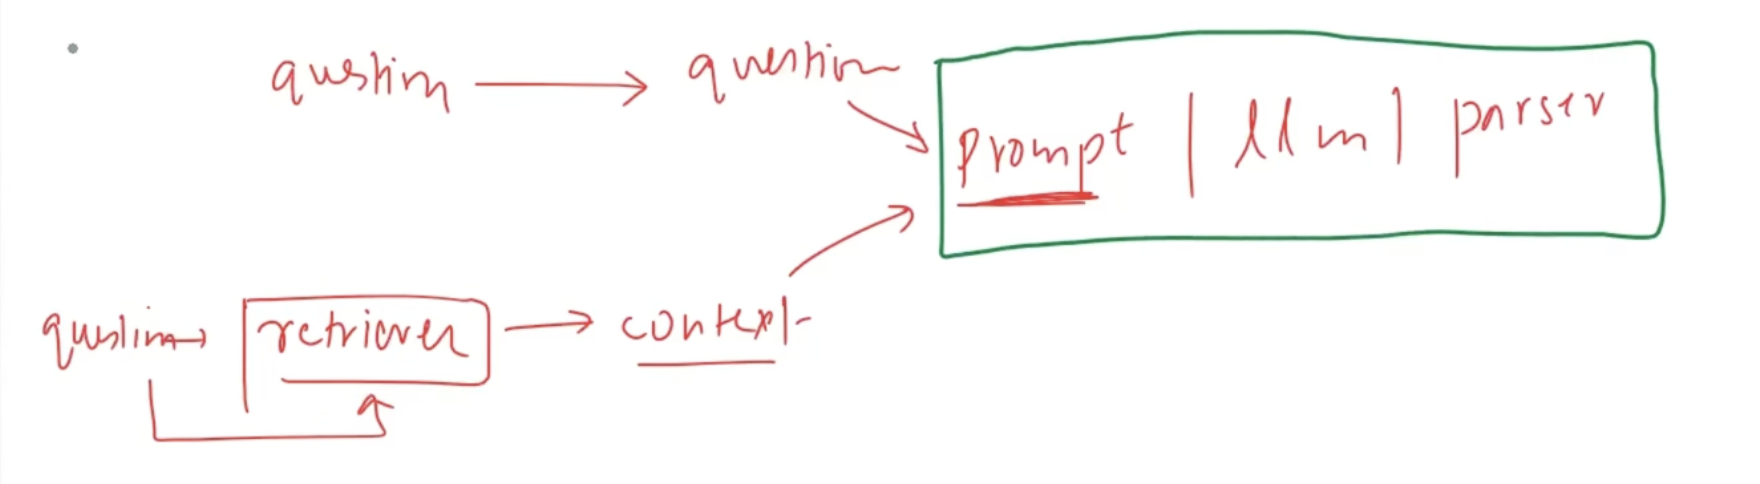

In [40]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

In [41]:
def format_docs(retrieved_docs):
  context_text = "\n\n".join(doc.page_content for doc in retrieved_docs)
  return context_text

In [42]:
parallel_chain = RunnableParallel({
    'context': retriever | RunnableLambda(format_docs),
    'question': RunnablePassthrough()
})

In [44]:
parallel_chain.invoke('What is AI Agent?')

{'context': "that but what actually is an AI agent well the clearest definition that I found that helps beginners to really wrap their head around what they are is this an AI agent is a digital worker that can understand instructions and take actions in order to complete tasks so in a very simple way just like businesses have employees who handle different tasks an AI agent is like having a digital employee but the cool thing is that you can build them and you can make them do whatever you want you're like literally building an employee that you can put to work to do things for you and of course they cost much less to run than a human and they don't need sick days and they don't start beef with Mike over in the sales department because of his comment at the coffee machine so I'm sure you can see the appeal of this kind of digital work and AI agents to businesses who are looking to adopt them in order to really understand why these AI agents are such a big deal we need to look at where 

In [45]:
parser = StrOutputParser()

In [46]:
main_chain = parallel_chain | prompt | llm | parser

In [47]:
main_chain.invoke('Can you summarize the video')

'The speaker creates content around building AI businesses. They encourage viewers to like, comment, and subscribe for more tutorials on this topic. The speaker shares a personal story of someone named Rory Ridges who joined their free community and applied the concepts learned from their videos to create his own content. The speaker then reveals a Figma board detailing various builds related to building AI businesses, and invites viewers to provide feedback through comments or likes.'

<h1 style="color:rgb(255, 98, 0);">Techniques to Improve RAG Systems</h1>

## 1. UI Enhancements
- **Current Issue**: Manual inputs in Colab notebook.
- **Improvements**:
  - **Create a Website**: Use tools like Streamlit where users can input YouTube URLs and chat.
  - **Build a Chrome Extension**: Activate on YouTube, allowing direct video-based chat without leaving the site.

## 2. Evaluation Enhancements
- **Current Issue**: No proper evaluation of RAG system.
- **Improvements**:
  - **Use RAGAS Library**:
    - Measures **Faithfulness** (is answer grounded in context?).
    - Measures **Relevancy** (is answer related to question?).
    - Measures **Context Precision** (usefulness of retrieved context).
    - Measures **Context Recall** (how much useful information was retrieved).
  - **Use LangSmith for Tracing**:
    - Track and debug each step of the RAG pipeline for better visibility.

## 3. Indexing Enhancements
- **Current Issue**: Simple ingestion from YouTube transcripts.
- **Improvements**:
  - **Fix Transcript Errors**: Clean auto-generated transcripts.
  - **Language Handling**:
    - Detect non-English transcripts.
    - Translate them into English before processing.
  - **Better Text Splitting**:
    - Instead of basic Recursive Character Splitter, use **Semantic Chunkers** to avoid splitting related content.
  - **Advanced Vector Stores**:
    - Instead of basic FAISS, use production-grade vector stores like **Pinecone**, **Weaviate**, etc.

## 4. Retrieval Enhancements
### Pre-Retrieval
- **Query Rewriting**:
  - Use LLMs to rewrite vague user queries for better retrieval.
- **Multi-Query Generation**:
  - Generate multiple queries from one to cover different angles.
- **Domain-Aware Routing**:
  - Route queries to different retrievers based on domain/type.

### During Retrieval
- **MMR (Maximal Marginal Relevance)**:
  - Balance between relevance and diversity of retrieved documents.
- **Hybrid Retrieval**:
  - Combine **Semantic Search** + **Keyword Search** for better results.
- **Re-ranking**:
  - Use an LLM to re-rank retrieved documents for better ordering.

### Post-Retrieval
- **Contextual Compression**:
  - Reduce unnecessary information in retrieved documents.
  - Keep only highly relevant parts to avoid token wastage in prompts.

---

# Summary
Improving a simple RAG system to industry-grade involves working on UI, Evaluation, Indexing, and Retrieval stages systematically, using better libraries, techniques, and scalable infrastructure.
